# Analiza podataka: Will it rain tomorrow in Australia?

Ovaj Jupyter Notebook sadrži detaljnu analizu vremenskog skupa podataka iz Australije, sa ciljem izgradnje modela za predikciju padavina za sutrašnji dan.

**Koraci analize:**
1. Učitavanje i opis skupa podataka
2. Ispitivanje nedostajućih vrednosti
3. Statistički pregled numeričkih i kategorijalnih promenljivih
4. Vizualizacija ključnih karakteristika
5. Detekcija i obrada neuravnoteženih klasa
6. Odabir najrelevantnijih karakteristika

---


In [58]:
# Učitavanje biblioteka i dataset-a
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prikaz svih kolona
pd.set_option('display.max_columns', None)

# Učitavanje podataka
df = pd.read_csv('weatherAUS_rainfall_prediction_dataset_cleaned.csv')

df.head()


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2010-04-30,Adelaide,10.8,21.2,0.0,1.8,6.60,ENE,22.0,ENE,NW,9.0,7.0,66.0,48.0,1028.4,1024.7,4.45,4.51,15.7,21.0,No,No
1,2014-07-22,Adelaide,3.7,19.0,0.0,1.4,7.61,N,24.0,N,NNE,0.0,11.0,75.0,32.0,1024.2,1021.1,4.45,4.51,9.6,18.5,No,No
2,2014-07-23,Adelaide,9.6,15.8,0.0,2.6,7.61,NE,52.0,NNE,NE,9.0,20.0,35.0,51.0,1017.9,1011.5,4.45,4.51,14.7,15.4,No,Yes
3,2014-07-24,Adelaide,10.1,15.5,16.6,0.8,7.61,NNE,50.0,NW,NW,17.0,26.0,96.0,80.0,1007.4,1008.0,4.45,4.51,11.2,14.0,Yes,Yes
4,2014-07-25,Adelaide,11.2,16.2,1.8,0.6,7.61,NW,30.0,WNW,WNW,13.0,15.0,89.0,70.0,1018.4,1019.2,4.45,4.51,13.0,15.3,Yes,Yes


In [59]:
# Opis strukture skupa podataka
print('Broj instanci:', df.shape[0])
print('Broj atributa:', df.shape[1])
print('\nTipovi podataka:')
print(df.dtypes)

print('\nPrvih 5 kolona:')
print(df.columns[:5].tolist())

# Provera prisustva ciljne promenljive
target = 'RainTomorrow'
if target in df.columns:
    print(f"Ciljna promenljiva '{target}' je prisutna.")
else:
    print(f"Ciljna promenljiva '{target}' NIJE pronađena!")


Broj instanci: 145460
Broj atributa: 23

Tipovi podataka:
Date              object
Location          object
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir       object
WindGustSpeed    float64
WindDir9am        object
WindDir3pm        object
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday         object
RainTomorrow      object
dtype: object

Prvih 5 kolona:
['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall']
Ciljna promenljiva 'RainTomorrow' je prisutna.


## Analiza nedostajućih vrednosti

U ovom delu analiziramo koje kolone imaju nedostajuće vrednosti, koliko ih ima i biramo strategiju za njihovo tretiranje (imputacija ili izbacivanje).


In [60]:
# Prikaz broja nedostajućih vrednosti po kolonama
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * mis_val / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Nedostajuće vrednosti', 1 : '% od ukupnog'}).sort_values('% od ukupnog', ascending=False)
    return mis_val_table_ren_columns[mis_val_table_ren_columns['Nedostajuće vrednosti'] > 0]

missing = missing_values_table(df)
missing


,Nedostajuće vrednosti,% od ukupnog


**Napomena:**
- Kolone sa velikim procentom nedostajućih vrednosti mogu biti izbačene.
- Za numeričke kolone sa manjim procentom nedostajućih vrednosti koristićemo imputaciju (npr. srednja/medijana vrednost).
- Za kategorijalne kolone koristićemo mod (najčešća vrednost) ili posebnu kategoriju "Unknown".

Definitivna strategija biće izabrana na osnovu rezultata prethodne analize.


## Statistički pregled numeričkih i kategorijalnih promenljivih


In [61]:
# Statistika za numeričke kolone
num_cols = df.select_dtypes(include=[np.number]).columns
print('Numeričke kolone:', num_cols.tolist())
df[num_cols].describe().T


Numeričke kolone: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


,count,mean,std,min,25%,50%,75%,max
MinTemp,145460.0,12.193993,6.365750,-8.5,7.70,12.10,16.80,33.9
MaxTemp,145460.0,23.221337,7.088124,-4.8,18.00,22.70,28.20,48.1
Rainfall,145460.0,2.360898,8.382488,0.0,0.00,0.00,1.00,371.0
Evaporation,145460.0,5.468995,3.161541,0.0,4.00,5.47,5.47,145.0
Sunshine,145460.0,7.610612,2.729486,0.0,7.61,7.61,8.70,14.5
WindGustSpeed,145460.0,40.035567,13.118253,6.0,31.00,39.00,46.00,135.0
WindSpeed9am,145460.0,14.043384,8.861059,0.0,7.00,13.00,19.00,130.0
WindSpeed3pm,145460.0,18.662601,8.716581,0.0,13.00,18.66,24.00,87.0
Humidity9am,145460.0,68.880816,18.854765,0.0,57.00,69.00,83.00,100.0
Humidity3pm,145460.0,51.539143,20.471189,0.0,37.00,51.54,65.00,100.0


In [62]:
# Statistika za kategorijalne kolone
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns
print('Kategorijalne kolone:', cat_cols.tolist())
df[cat_cols].describe().T


Kategorijalne kolone: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


,count,unique,top,freq
Date,145460,3436,2017-04-10,49
Location,145460,49,Canberra,3436
WindGustDir,145460,16,W,20241
WindDir9am,145460,16,N,22324
WindDir3pm,145460,16,SE,15066
RainToday,145460,2,No,113580
RainTomorrow,145460,2,No,113583


## Vizuelizacija ključnih karakteristika podataka


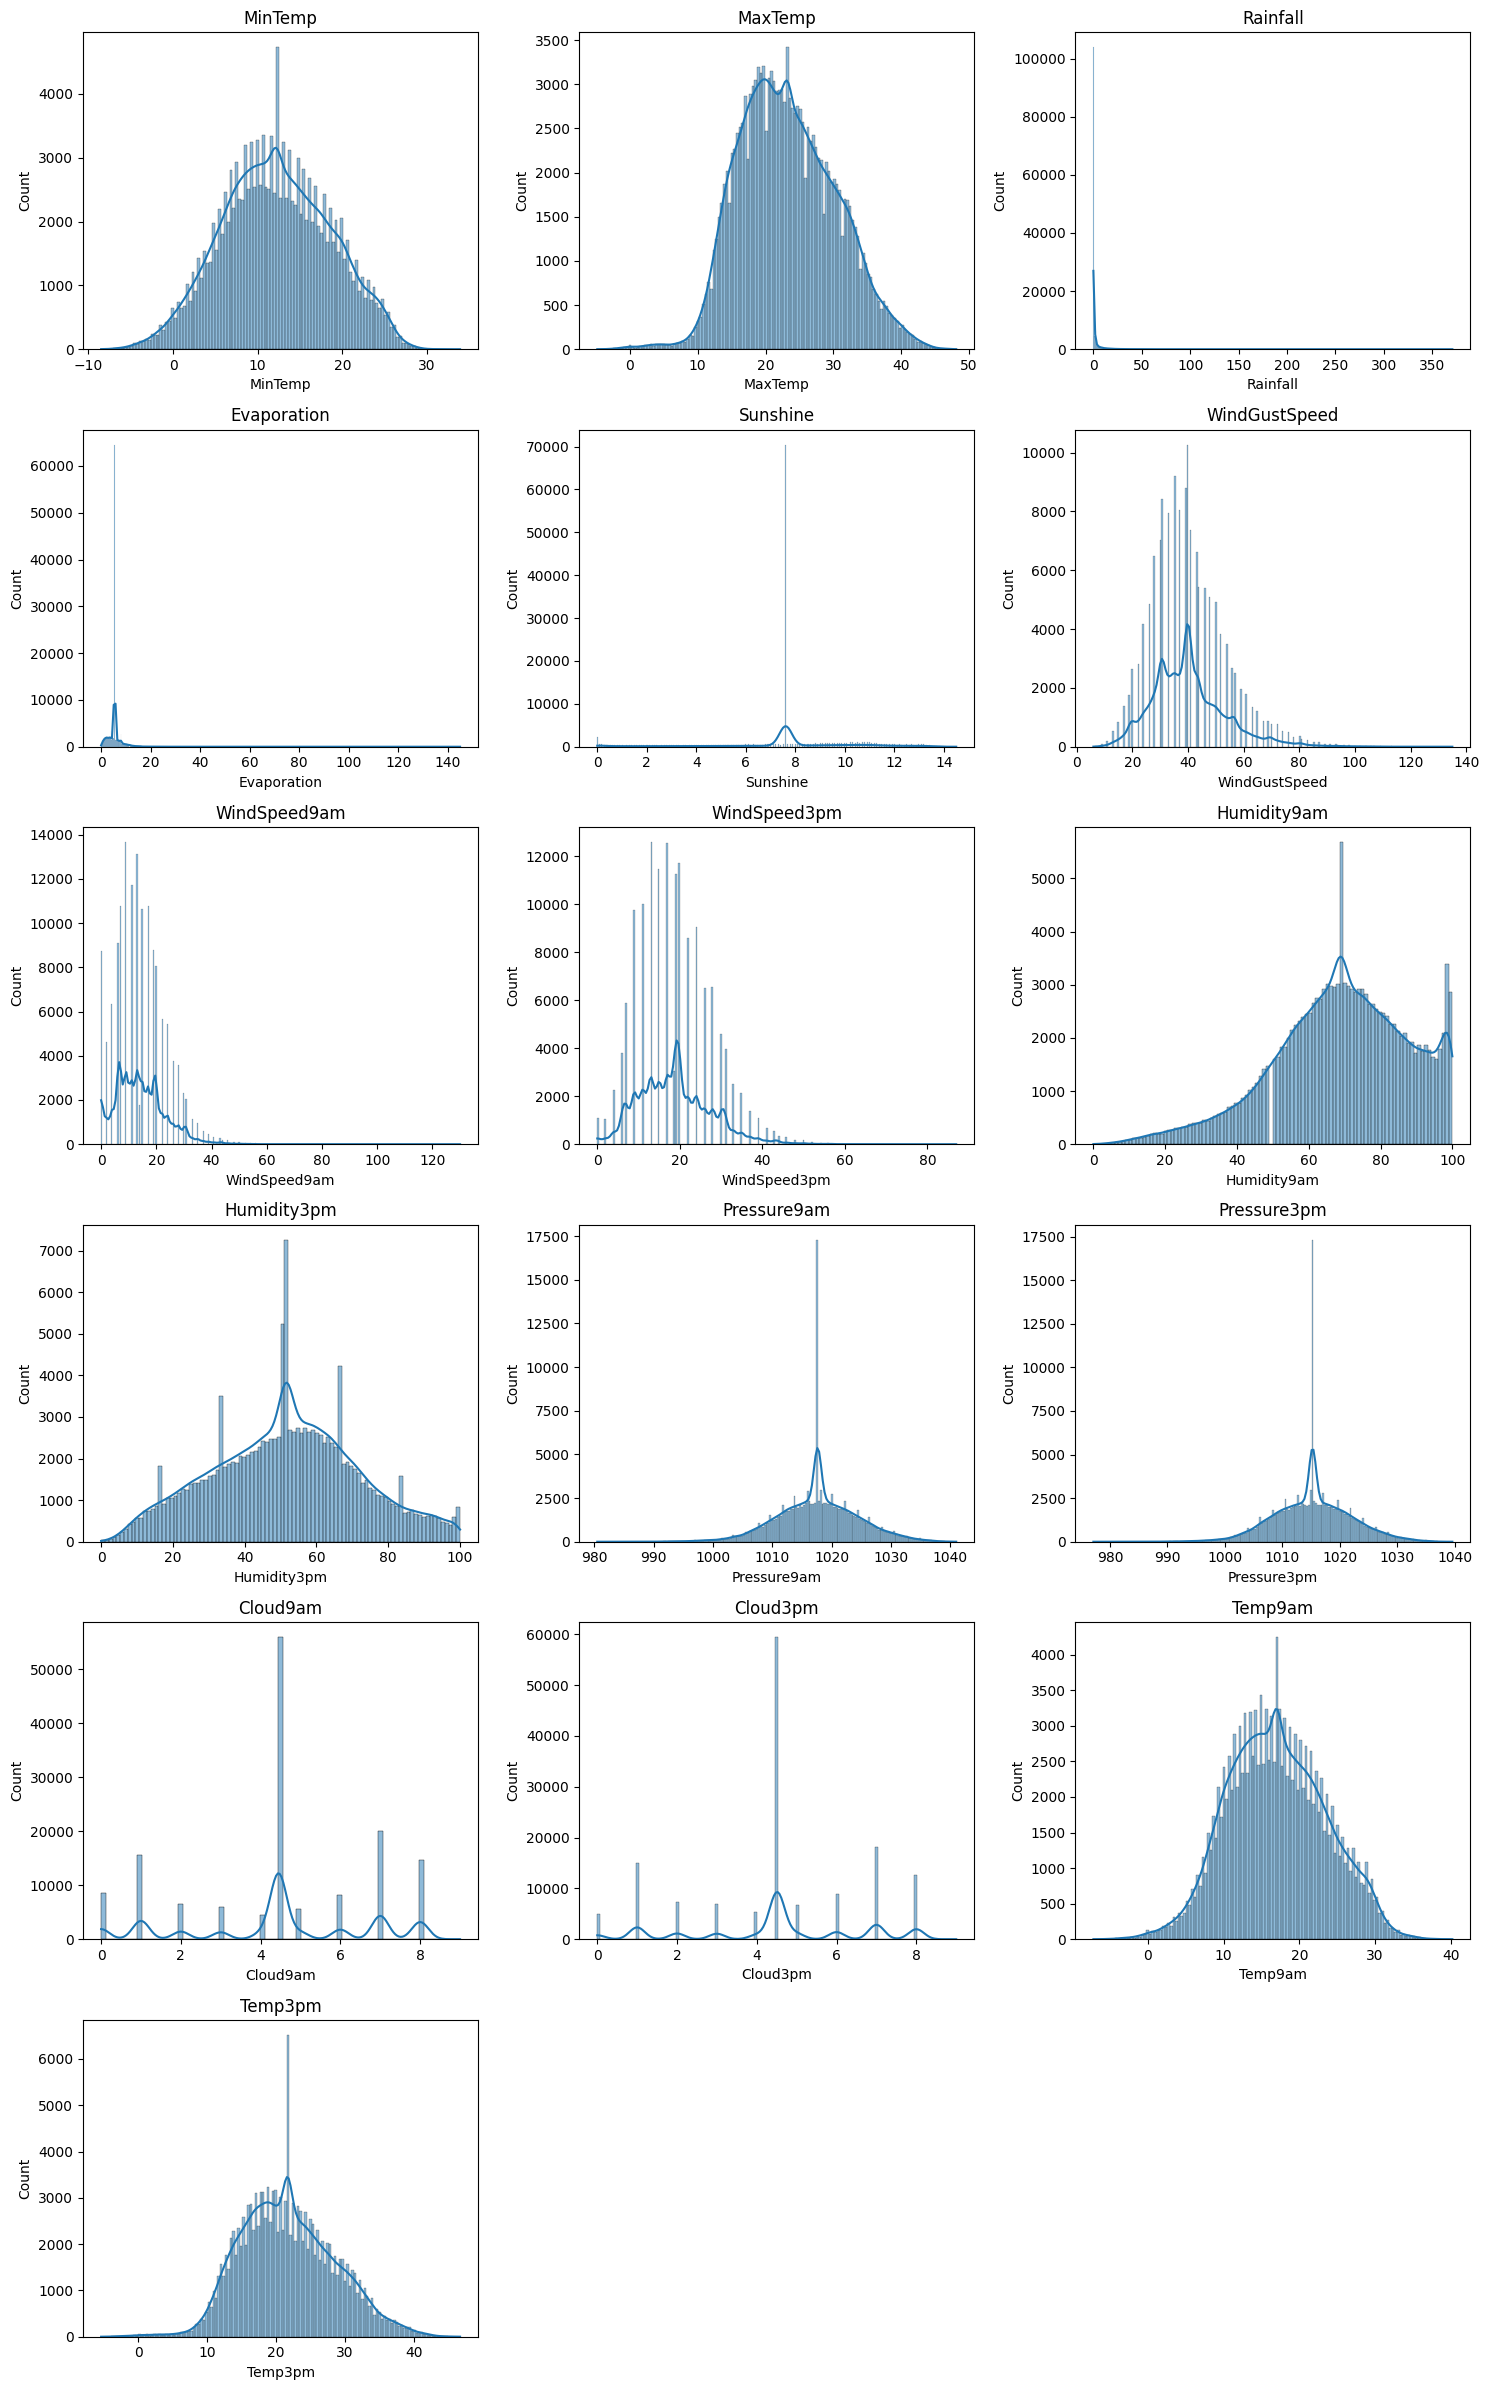

In [72]:
# Numeric distributions
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
fig, axes = plt.subplots(nrows=int(np.ceil(len(numeric_columns)/3)), ncols=3, figsize=(15, 4*int(np.ceil(len(numeric_columns)/3))))
axes = axes.flatten()
for i, col in enumerate(numeric_columns):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()
plt.show()


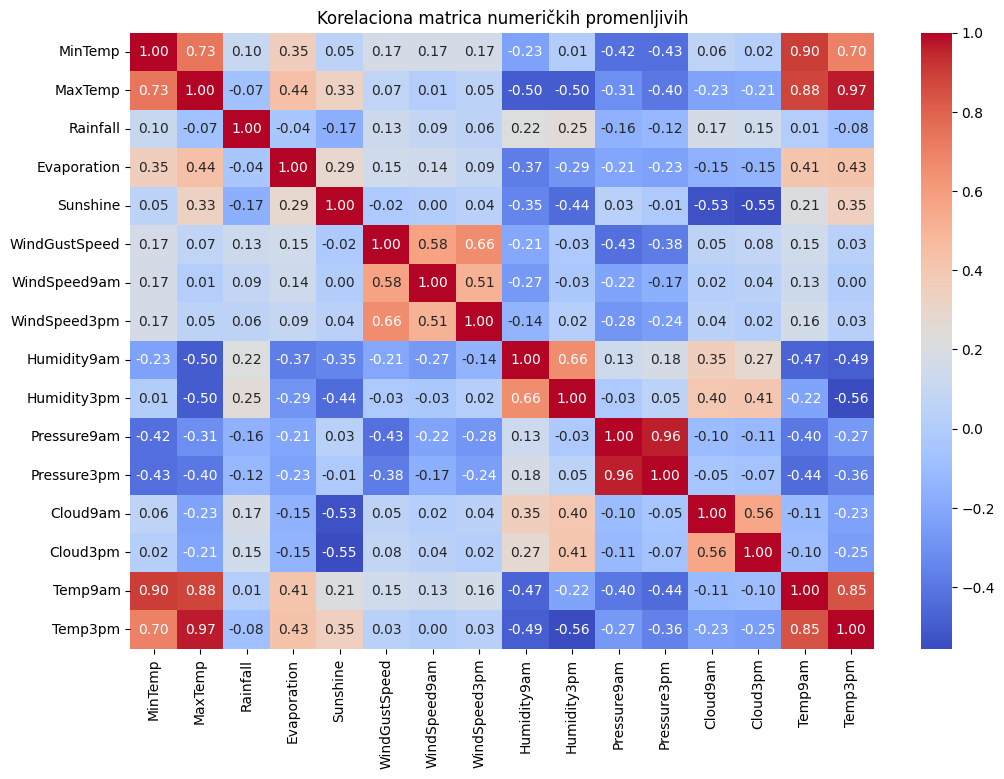

In [64]:
# Korelaciona matrica
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelaciona matrica numeričkih promenljivih')
plt.show()


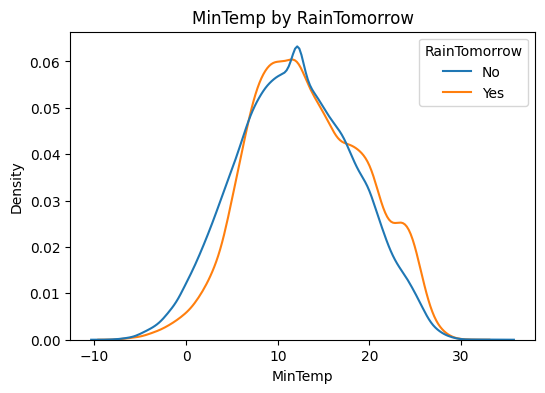

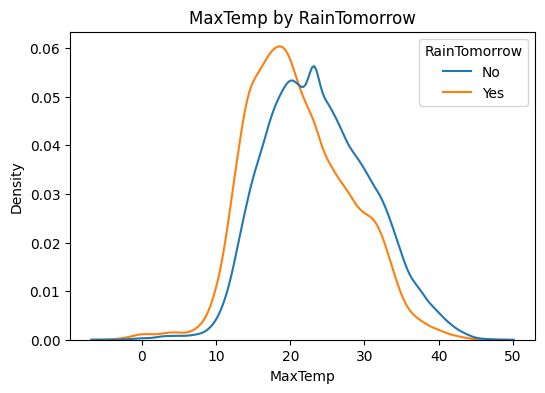

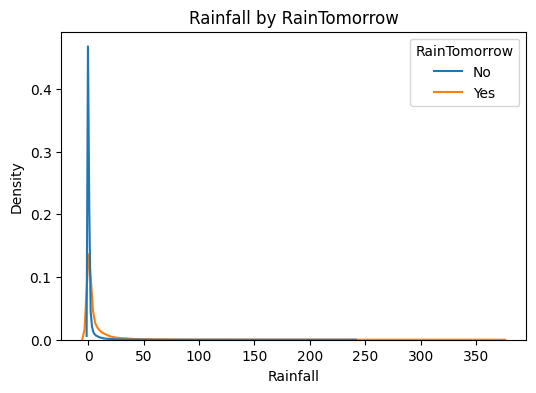

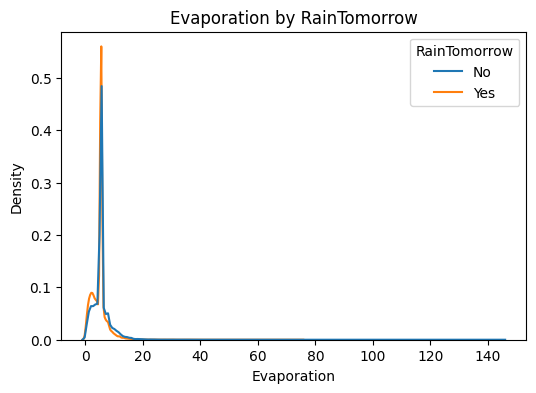

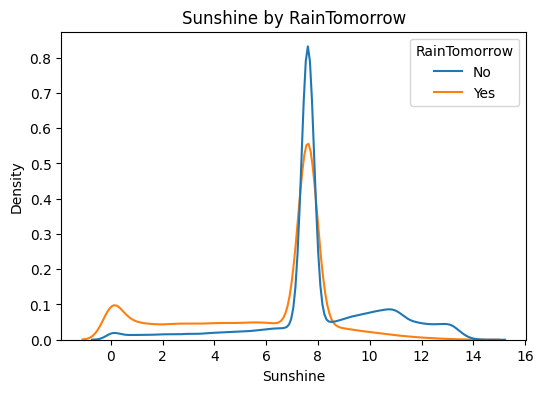

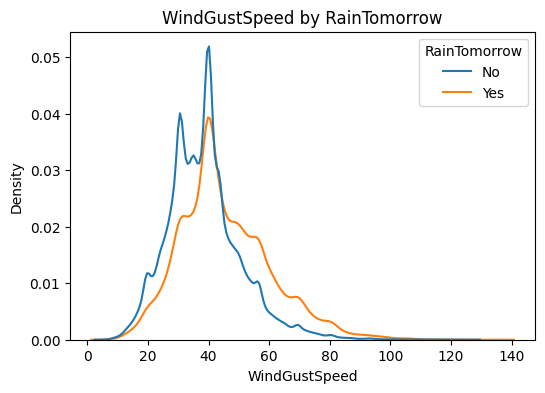

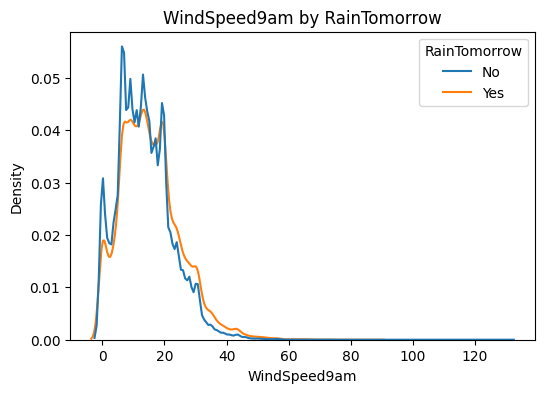

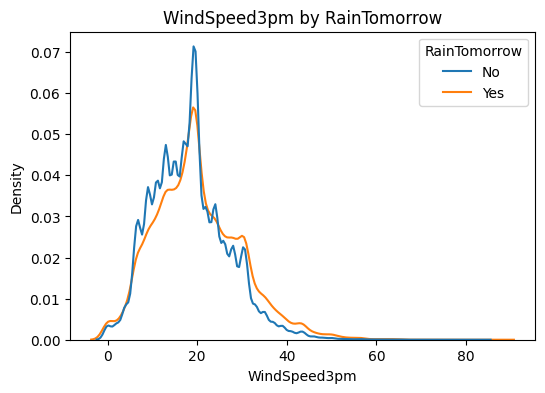

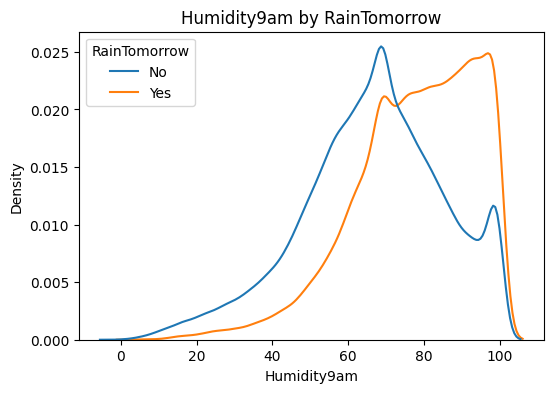

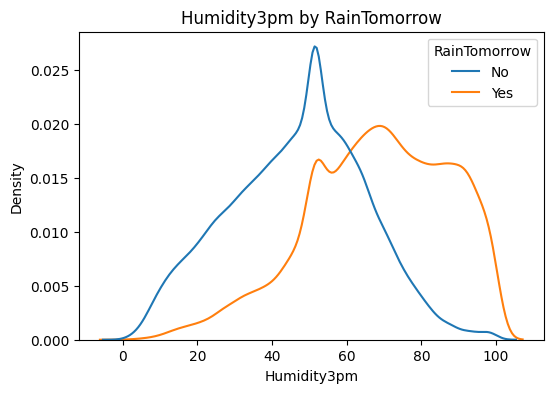

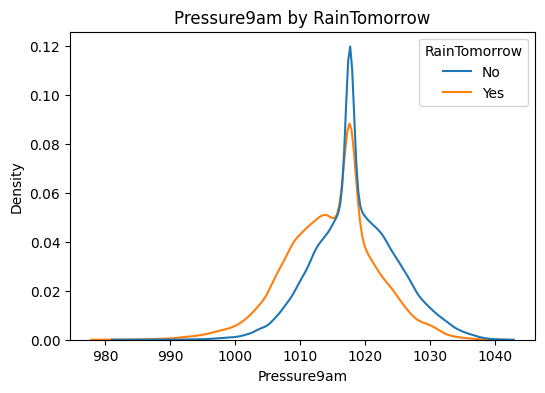

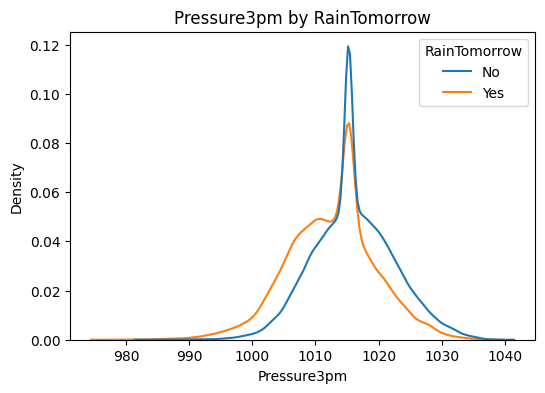

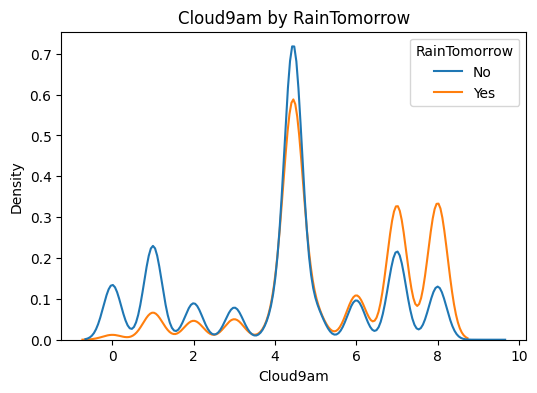

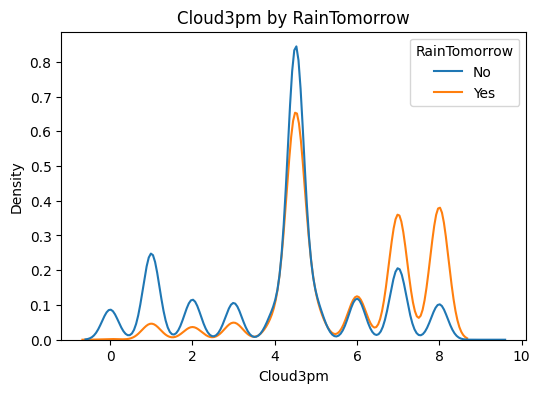

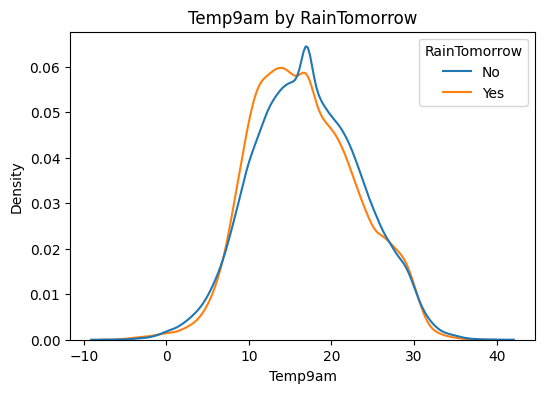

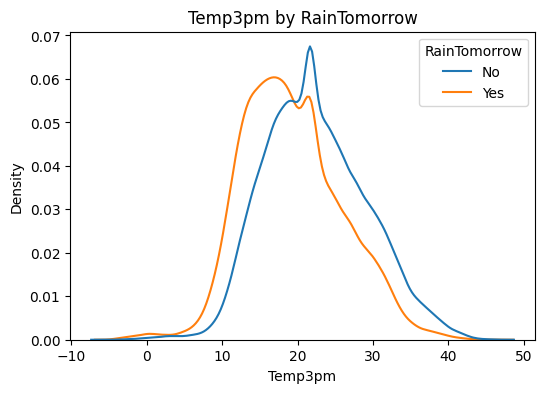

In [70]:
# Target relationships: numeric vs target
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
for col in numeric_columns:
    plt.figure(figsize=(6, 4))
    sns.kdeplot(data=df, x=col, hue='RainTomorrow', common_norm=False)
    plt.title(f"{col} by RainTomorrow")
    plt.show()

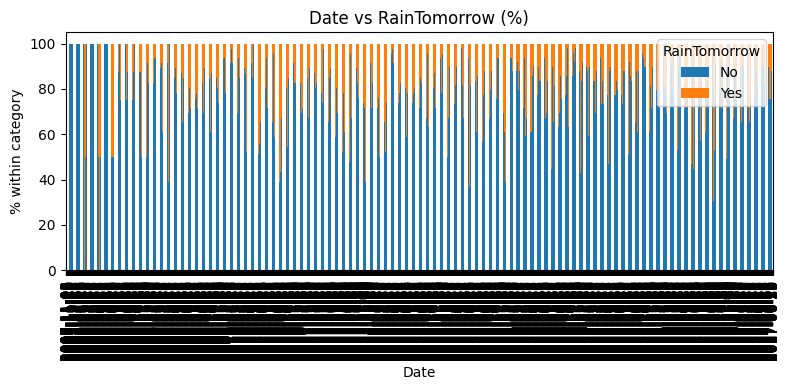

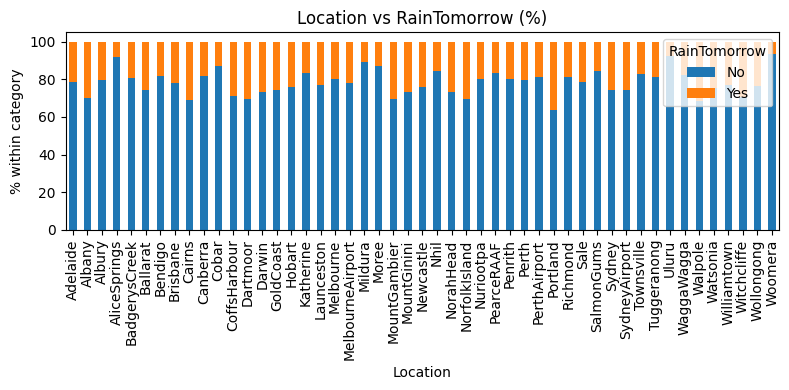

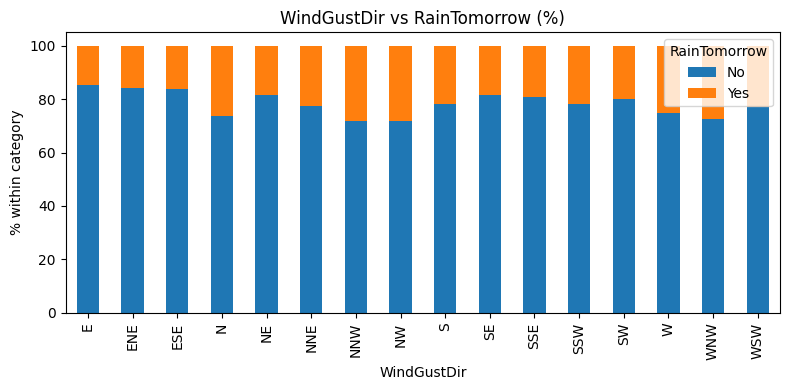

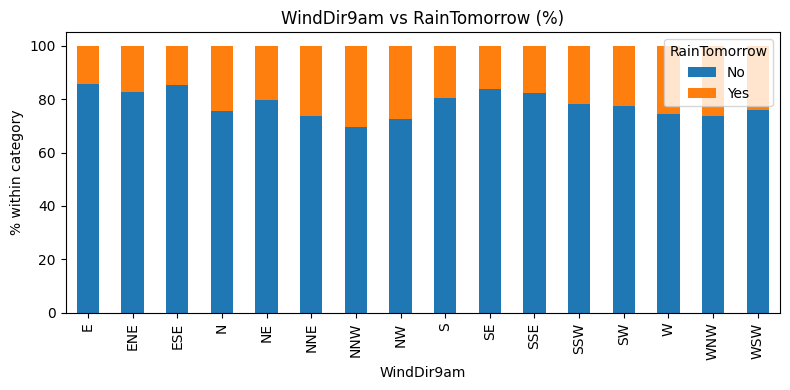

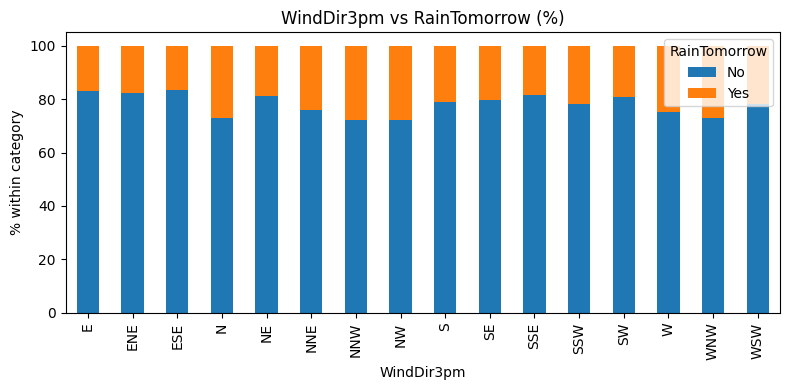

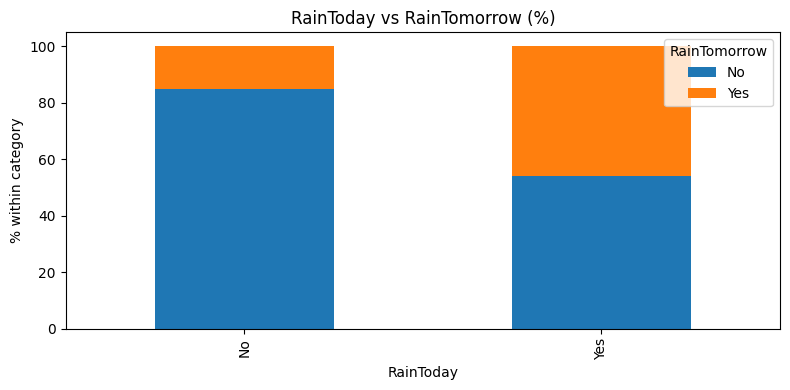

In [71]:
# Target relationships: categorical vs target (stacked percentages)
cat_cols = df.select_dtypes(include=['object']).columns.drop('RainTomorrow')

for col in cat_cols:
    ct = pd.crosstab(df[col], df['RainTomorrow'], normalize='index') * 100
    ct = ct[['No', 'Yes']] if 'No' in ct.columns and 'Yes' in ct.columns else ct
    ct.plot(kind='bar', stacked=True, figsize=(8, 4))
    plt.title(f"{col} vs RainTomorrow (%)")
    plt.ylabel('% within category')
    plt.legend(title='RainTomorrow', loc='upper right')
    plt.tight_layout()
    plt.show()

## Detekcija i obrada neuravnoteženih klasa


RainTomorrow
No     0.780854
Yes    0.219146
Name: proportion, dtype: float64


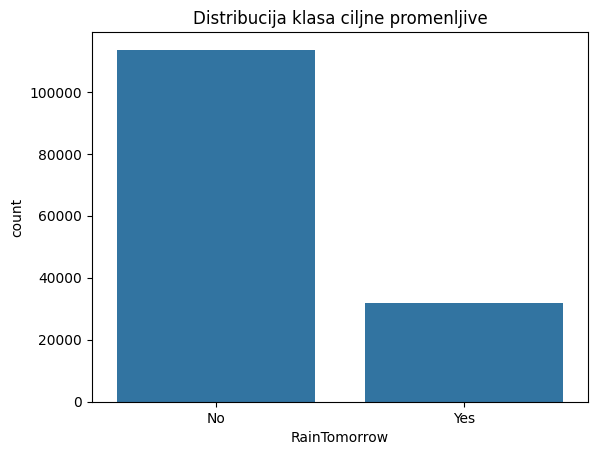

In [66]:
# Provera balansa klasa ciljne promenljive
if target in df.columns:
    print(df[target].value_counts(normalize=True))
    sns.countplot(x=target, data=df)
    plt.title('Distribucija klasa ciljne promenljive')
    plt.show()
else:
    print('Ciljna promenljiva nije pronađena!')


In [67]:
# Balance classes and save a new CSV
from sklearn.utils import resample


def balance_classes_and_save(
    dataframe: pd.DataFrame,
    target_column: str = 'RainTomorrow',
    positive_label: str = 'Yes',
    output_path: str = 'weatherAUS_rainfall_prediction_dataset_cleaned_balanced.csv',
    strategy: str = 'oversample',  # 'oversample' or 'undersample'
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Balance classes and save to CSV.
    - oversample: upsample the minority to the majority count (keeps dataset large)
    - undersample: downsample the majority to the minority count (shrinks dataset)
    """
    df_local = dataframe.copy()
    minority_df = df_local[df_local[target_column] == positive_label]
    majority_df = df_local[df_local[target_column] != positive_label]

    if len(minority_df) == 0 or len(majority_df) == 0:
        raise ValueError('Both classes must be present to balance.')

    if strategy == 'oversample':
        target_size = len(majority_df)
        minority_up = resample(
            minority_df,
            replace=True,
            n_samples=target_size,
            random_state=random_state
        )
        balanced_df = pd.concat([majority_df, minority_up], axis=0)
    elif strategy == 'undersample':
        target_size = len(minority_df)
        majority_down = resample(
            majority_df,
            replace=False,
            n_samples=target_size,
            random_state=random_state
        )
        balanced_df = pd.concat([minority_df, majority_down], axis=0)
    else:
        raise ValueError("strategy must be 'oversample' or 'undersample'")

    balanced_df = balanced_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    balanced_df.to_csv(output_path, index=False)
    print(f"Saved balanced dataset to {output_path} with shape {balanced_df.shape}")
    print(balanced_df[target_column].value_counts())
    return balanced_df

# Execute balancing with oversampling to avoid shrinking the dataset
balanced_df = balance_classes_and_save(df, strategy='oversample')
balanced_df.head()


Saved balanced dataset to weatherAUS_rainfall_prediction_dataset_cleaned_balanced.csv with shape (227166, 23)
RainTomorrow
Yes    113583
No     113583
Name: count, dtype: int64


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-11-19,Sydney,17.0,22.1,6.2,7.80,1.00,W,40.04,NNE,E,9.0,20.0,91.0,78.0,1011.40,1008.20,8.00,8.00,18.4,20.9,Yes,Yes
1,2014-05-25,Witchcliffe,13.2,17.9,4.0,5.47,7.61,NW,43.00,WNW,WSW,20.0,22.0,63.0,70.0,1011.20,1010.10,4.45,4.51,16.2,16.2,Yes,Yes
2,2016-12-23,MountGinini,7.0,22.5,0.0,5.47,7.61,NW,31.00,WNW,WNW,11.0,13.0,65.0,48.0,1017.65,1015.26,4.45,4.51,14.6,20.8,No,No
3,2015-06-29,Tuggeranong,-2.4,14.3,0.0,5.47,7.61,NNW,17.00,N,NNW,0.0,7.0,84.0,48.0,1034.60,1030.30,4.45,4.51,4.0,13.9,No,No
4,2009-03-09,Cobar,21.1,33.4,0.0,10.40,11.20,E,41.00,ENE,ENE,24.0,9.0,52.0,29.0,1015.80,1013.20,3.00,6.00,22.5,31.3,No,No


In [68]:
balanced_df.head

<bound method NDFrame.head of               Date      Location  MinTemp  MaxTemp  Rainfall  Evaporation  \
0       2008-11-19        Sydney     17.0     22.1       6.2         7.80   
1       2014-05-25   Witchcliffe     13.2     17.9       4.0         5.47   
2       2016-12-23   MountGinini      7.0     22.5       0.0         5.47   
3       2015-06-29   Tuggeranong     -2.4     14.3       0.0         5.47   
4       2009-03-09         Cobar     21.1     33.4       0.0        10.40   
...            ...           ...      ...      ...       ...          ...   
227161  2016-10-03   Tuggeranong      9.0     14.2       9.8         5.47   
227162  2012-09-22      Watsonia     10.6     20.4       1.0         3.80   
227163  2011-05-13      Dartmoor      8.9     14.3       3.2         0.40   
227164  2013-06-22      Adelaide      9.7     13.7      12.8         5.47   
227165  2009-08-30  MountGambier      5.4     13.2      10.8         1.80   

        Sunshine WindGustDir  WindGustSpeed W

RainTomorrow
Yes    0.5
No     0.5
Name: proportion, dtype: float64


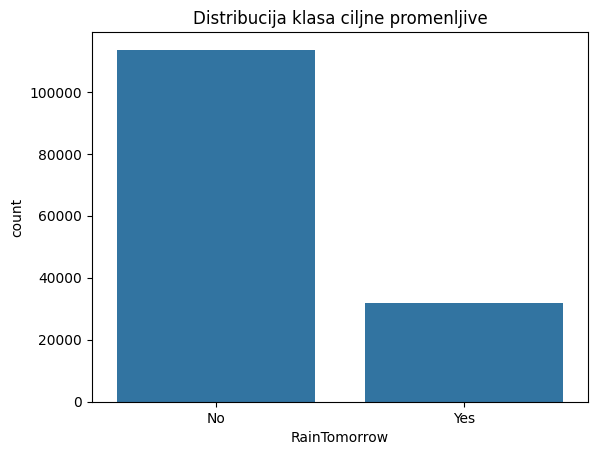

In [69]:
# Provera balansa klasa ciljne promenljive
if target in balanced_df.columns:
    print(balanced_df[target].value_counts(normalize=True))
    sns.countplot(x=target, data=df)
    plt.title('Distribucija klasa ciljne promenljive')
    plt.show()
else:
    print('Ciljna promenljiva nije pronađena!')


## Odabir najrelevantnijih karakteristika

Na osnovu prethodnih analiza (statistika, korelacija, vizualizacija), biramo najrelevantnije karakteristike za modeliranje. U obzir se uzimaju:
- Visoka korelacija sa ciljnom promenljivom
- Niska međusobna korelacija (da se izbegne multikolinearnost)
- Značaj u domenskom smislu (npr. padavine, temperatura, vlažnost)

**Obrazloženje izbora karakteristika biće dodatno opisano u izveštaju.**
